In [132]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

## Phase 1: Lexicon Setup

In [133]:
# 1. Clean the environment (the -f flag prevents errors if the file doesn't exist yet)
!rm -f names.txt*

# 2. Download a fresh, clean copy
!wget -q -O names.txt https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

In [134]:
with open('names.txt', 'r') as file:
    words = file.read().splitlines()
# How it works:
# 1. open(..., 'r') : Opens the file in read-only mode (prevents accidental edits).
# 2. .read()        : Grabs the entire file as one giant string.
# 3. .splitlines()  : Chops that string at every line break to create a clean list.

In [135]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## Phase 2: Dataset Construction

In [136]:
# build the dataset

# Context Length: 3 characters provides enough historical memory to predict
# basic patterns without causing a blowup in tensor size.

block_size = 3
def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y


# --- DATASET SPLITS (80/10/10) ---
# Training Split (80%): Used exclusively to calculate gradients and update model weights.
# Dev/Validation Split (10%): Used to tune hyperparameters without updating weights.
# Acts as an early-warning system for overfitting (memorization).
# Test Split (10%): The locked vault. Evaluated exactly once at the end for true model performance.


import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## Phase 3: Architecture Initialization

In [137]:
g = torch.Generator().manual_seed(2147483647) # for hardware-level reproducibility

# Dimensions optimized via the Dev split:
# 10D Embedding: Provides sufficient spatial volume to cluster character relationships (e.g. vowels vs consonants).
# 200 Hidden Neurons: Expands computational capacity to learn complex sequences without

C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

## Phase 4: Training

In [138]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [139]:
for p in parameters:
  p.requires_grad = True

In [140]:
lri =[]
lossi =[]
stepi =[]


In [148]:

for i in range(100000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  #forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)

  loss = F.cross_entropy(logits, Ytr[ix])
  if i % 5000 == 0: print(f"Step {i}: Loss {loss.item():.4f}")
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  for p in parameters:
    lr = 0.01
    p.data += -lr * p.grad

  #track stats
  # lri.append(lre[i])
  lossi.append(loss.log10().item())
  stepi.append(i)

Step 0: Loss 2.3076
Step 5000: Loss 2.1843
Step 10000: Loss 2.6446
Step 15000: Loss 1.9843
Step 20000: Loss 2.7408
Step 25000: Loss 2.2220
Step 30000: Loss 2.4816
Step 35000: Loss 2.5629
Step 40000: Loss 2.1257
Step 45000: Loss 2.2524
Step 50000: Loss 2.5573
Step 55000: Loss 2.1074
Step 60000: Loss 2.1645
Step 65000: Loss 2.4485
Step 70000: Loss 2.8721
Step 75000: Loss 2.1295
Step 80000: Loss 2.4230
Step 85000: Loss 2.5309
Step 90000: Loss 1.9688
Step 95000: Loss 2.3004


## Phase 5: Evaluation

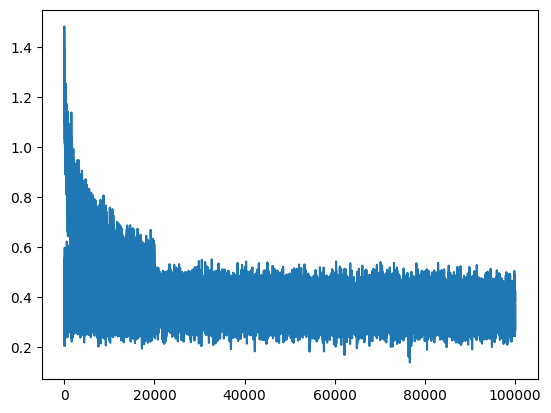

In [149]:
plt.plot(stepi,lossi)
# Note: The noise at the bottom of the loss curve is due to minibatch variance.

In [150]:
#1. Training Loss
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3011, grad_fn=<NllLossBackward0>)

In [151]:
#2. Dev Loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3140, grad_fn=<NllLossBackward0>)

In [152]:
#3. Test Loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.3213, grad_fn=<NllLossBackward0>)

## Phase 6: Inference

In [146]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10) #

for _ in range(20): # Generate 20 words
    out = [] #
    context = [0] * block_size # initialize with all ...

    while True: #
        # 1. Forward Pass (Batch size of 1)
        emb = C[torch.tensor([context])] # Shape: (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1) #
        logits = h @ W2 + b2 #

        # 2. Probability Distribution
        probs = F.softmax(logits, dim=1) #

        # 3. The Dice Roll
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() #

        # 4. Slide the Window
        context = context[1:] + [ix] #
        out.append(ix) #

        # 5. The Stop Condition
        if ix == 0: #
            break #

    print(''.join(itos[i] for i in out)) # Decode and print

caruah.
amorilesh.
jarle.
tatyah.
cayta.
jazhunn.
deerah.
jageei.
nertara.
chaiir.
asleig.
dham.
joce.
quinn.
salin.
alianbr.
wanta.
giearixi.
faneelinra.
med.
